# SupplyPrescript

## Notebook 5: Shipment Delay Prediction using Machine Learning

### Objective

The objective of this notebook is to build predictive models that identify shipments at risk of late delivery.

The notebook includes:

- Loading prepared datasets
- Training baseline and advanced models
- Model evaluation
- Performance comparison
- Feature importance analysis
- Hyperparameter tuning
- Saving the best model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(144415, 33)
(36104, 33)
(144415,)
(36104,)


## Why Random Forest?

Random Forest provides a strong baseline for structured tabular datasets and allows comparison with XGBoost.

In [4]:
rf = RandomForestClassifier(

    random_state=42,

    n_estimators=200

)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
rf_pred = rf.predict(X_test)

In [6]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("Precision:", precision_score(y_test, rf_pred))

print("Recall:", recall_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.9643806780412143
Precision: 0.9519925766751318
Recall: 0.9846938775510204
F1 Score: 0.968067143424712


In [7]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     16308
           1       0.95      0.98      0.97     19796

    accuracy                           0.96     36104
   macro avg       0.97      0.96      0.96     36104
weighted avg       0.96      0.96      0.96     36104



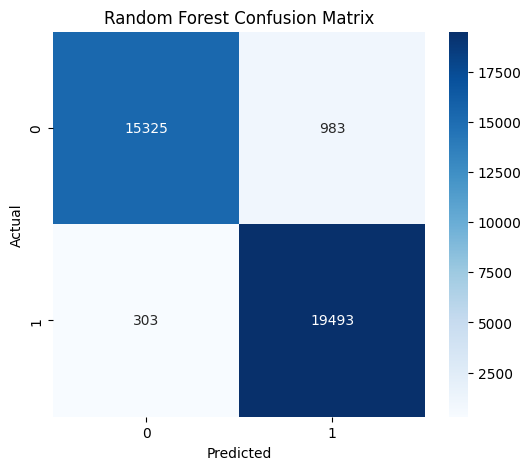

In [8]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

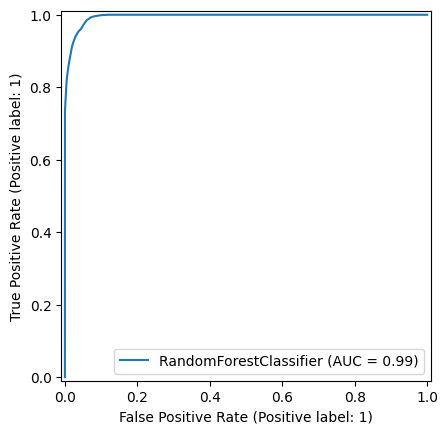

In [9]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.show()

In [10]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf.feature_importances_

})

In [11]:
importance = importance.sort_values(

    by="Importance",

    ascending=False
)

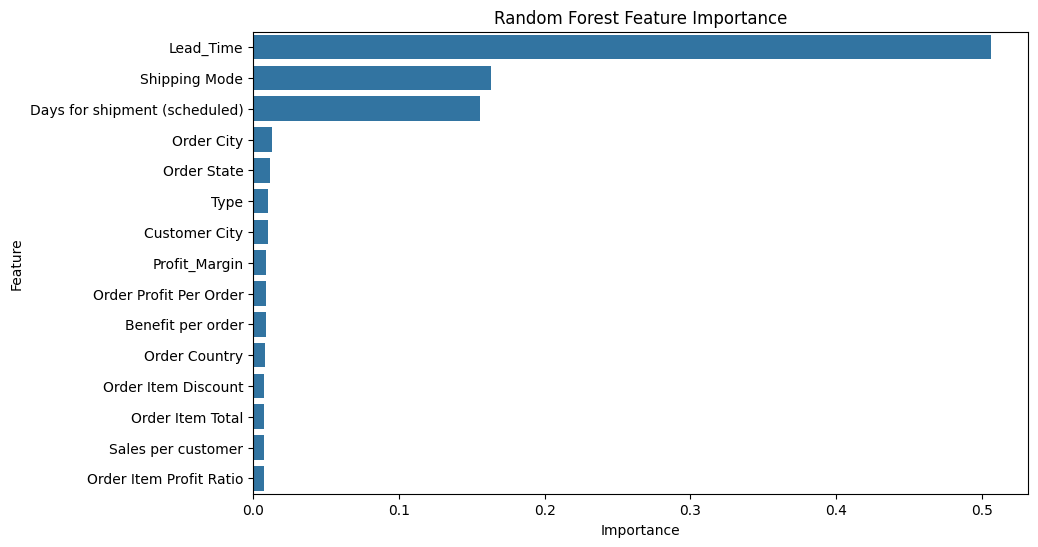

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

## XGBoost

XGBoost is a gradient boosting algorithm that generally performs better than Random Forest on structured business datasets.

In [13]:
xgb = XGBClassifier(

    random_state=42,

    learning_rate=0.1,

    n_estimators=300,

    max_depth=6,

    eval_metric="logloss"

)

In [14]:
xgb.fit(

    X_train,

    y_train

)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [15]:
xgb_pred = xgb.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("Precision:", precision_score(y_test, xgb_pred))

print("Recall:", recall_score(y_test, xgb_pred))

print("F1:", f1_score(y_test, xgb_pred))

print("ROC AUC:", roc_auc_score(y_test, xgb_pred))

Accuracy: 0.9649346332816309
Precision: 0.9529233476730543
Recall: 0.9846938775510204
F1: 0.9685481466759416
ROC AUC: 0.9628215524620444


In [17]:
print(classification_report(

    y_test,

    xgb_pred

))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     16308
           1       0.95      0.98      0.97     19796

    accuracy                           0.96     36104
   macro avg       0.97      0.96      0.96     36104
weighted avg       0.97      0.96      0.96     36104



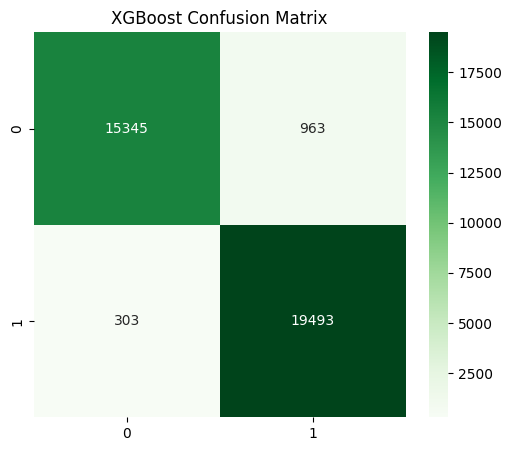

In [18]:
cm = confusion_matrix(

    y_test,

    xgb_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.title("XGBoost Confusion Matrix")

plt.show()

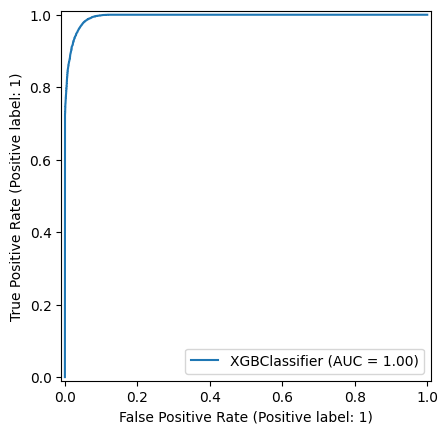

In [19]:
RocCurveDisplay.from_estimator(

    xgb,

    X_test,

    y_test

)

plt.show()

In [20]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb.feature_importances_

})

In [21]:
importance = importance.sort_values(

    by="Importance",

    ascending=False

)

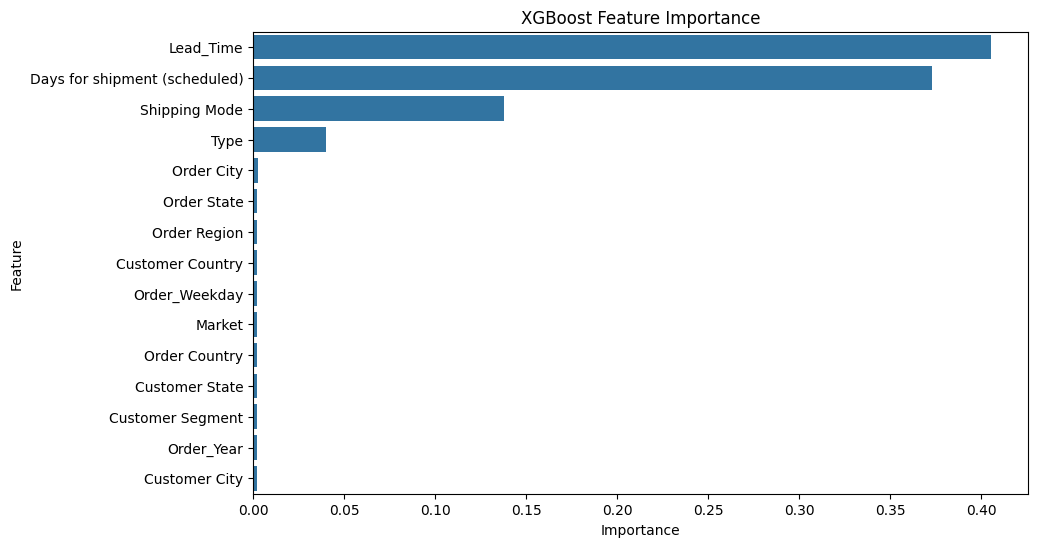

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("XGBoost Feature Importance")

plt.show()

In [23]:
results = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, xgb_pred)

    ],

    "Precision":[

        precision_score(y_test, rf_pred),

        precision_score(y_test, xgb_pred)

    ],

    "Recall":[

        recall_score(y_test, rf_pred),

        recall_score(y_test, xgb_pred)

    ],

    "F1":[

        f1_score(y_test, rf_pred),

        f1_score(y_test, xgb_pred)

    ]

})

In [24]:
results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.964381,0.951993,0.984694,0.968067
1,XGBoost,0.964935,0.952923,0.984694,0.968548


In [35]:
Best_model = xgb

In [49]:


joblib.dump(Best_model, "../models/Best_model.pkl")

print("Saved successfully!")

Saved successfully!


In [50]:
importance.to_csv(

    "../models/feature_importance.csv",

    index=False

)

# Summary

Two machine learning models were trained and evaluated:

- Random Forest
- XGBoost

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

Feature importance analysis identified the variables contributing most to shipment delay prediction.

The best-performing model was saved for deployment in the backend.